# Insider purchases in small-cap biotech

## A presentation-ready event study, 2009–2025

**Question.** Do publicly disclosed Form 4 insider trades in U.S. biotech predict stock returns relative to XBI?

**Design.** One observation is an issuer × filing date × direction. Entry is the close of the first exchange session strictly after the filing. Returns are stock total return minus XBI total return over identical sessions. The pre-registered headline horizon remains **5 sessions**. Inference uses issuer × filing-month two-way clustered standard errors.

- **S1 — teal:** small-cap purchases; lagged market cap in the lower tercile using prior-years-only breakpoints.
- **S2 — blue:** all purchases.
- **S3 — rose:** sales.

All displayed numbers are computed by the package functions in `data.py`, `signals.py`, `evaluate.py`, and the additive presentation layer in `report.py`.

In [1]:
# Setup: make the repository root importable, then run the full official analysis once.
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared").is_dir())
# Import from the repository root; drop the notebook folder so its signals.py does not shadow the signals package.
sys.path = [str(ROOT)] + [p for p in sys.path if p not in ("", str(Path.cwd()))]
import pandas as pd
from IPython.display import HTML, Image, Markdown, display

from shared.config import DEFAULT_CONFIG
from signals.smallcap_purchases.report import (
    build_presentation_outputs, format_example_table, format_inference_table,
    run_analysis, write_report,
)

# Official run: full-universe CRSP prices; results/ tables and figures are rewritten.
config = DEFAULT_CONFIG.with_price_source("universe_full")
analysis = run_analysis(config)
official_summary = write_report(analysis, config)
presentation = build_presentation_outputs(analysis, config)

# One-table summary of what this run covers.
run_summary = pd.DataFrame([
    ("Universe", f"{analysis['coverage']['universe_permnos']:,} historical biotech securities"),
    ("Study period", f"{config.study_start[:4]}–{config.study_end[:4]}"),
    ("S1 events", f"{len(analysis['signals']['S1']):,}"),
    ("S2 events", f"{len(analysis['signals']['S2']):,}"),
    ("S3 events", f"{len(analysis['signals']['S3']):,}"),
    ("Price source", f"CRSP {official_summary['price_source']}"),
    ("Tests", "python shared/tests/run_tests.py (run before delivery)"),
], columns=["Run item", "Value"])
display(HTML(run_summary.to_html(index=False)))

Run item,Value
Universe,953 historical biotech securities
Study period,2009–2025
S1 events,"3,537"
S2 events,"11,327"
S3 events,"30,177"
Price source,CRSP universe_full
Tests,python shared/tests/run_tests.py (run before delivery)


## A. Data & coverage

The universe is the validated historical `universe_v4`, including firms that later delisted. “Priced” means at least one CRSP daily record is available for the security. Event counts below are signal issuer-days, not individual transaction rows.

measure,value
Universe securities (PERMNOs),953
Universe securities with prices,953
S1 events,3537
S2 events,11327
S3 events,30177


signal,S1,S2,S3
year,,,
2009,188,472,865
2010,108,500,878
2011,103,559,1061
2012,104,566,1077
2013,81,565,1219
2014,121,736,1814
2015,219,719,2205
2016,234,723,1407
2017,196,663,1481


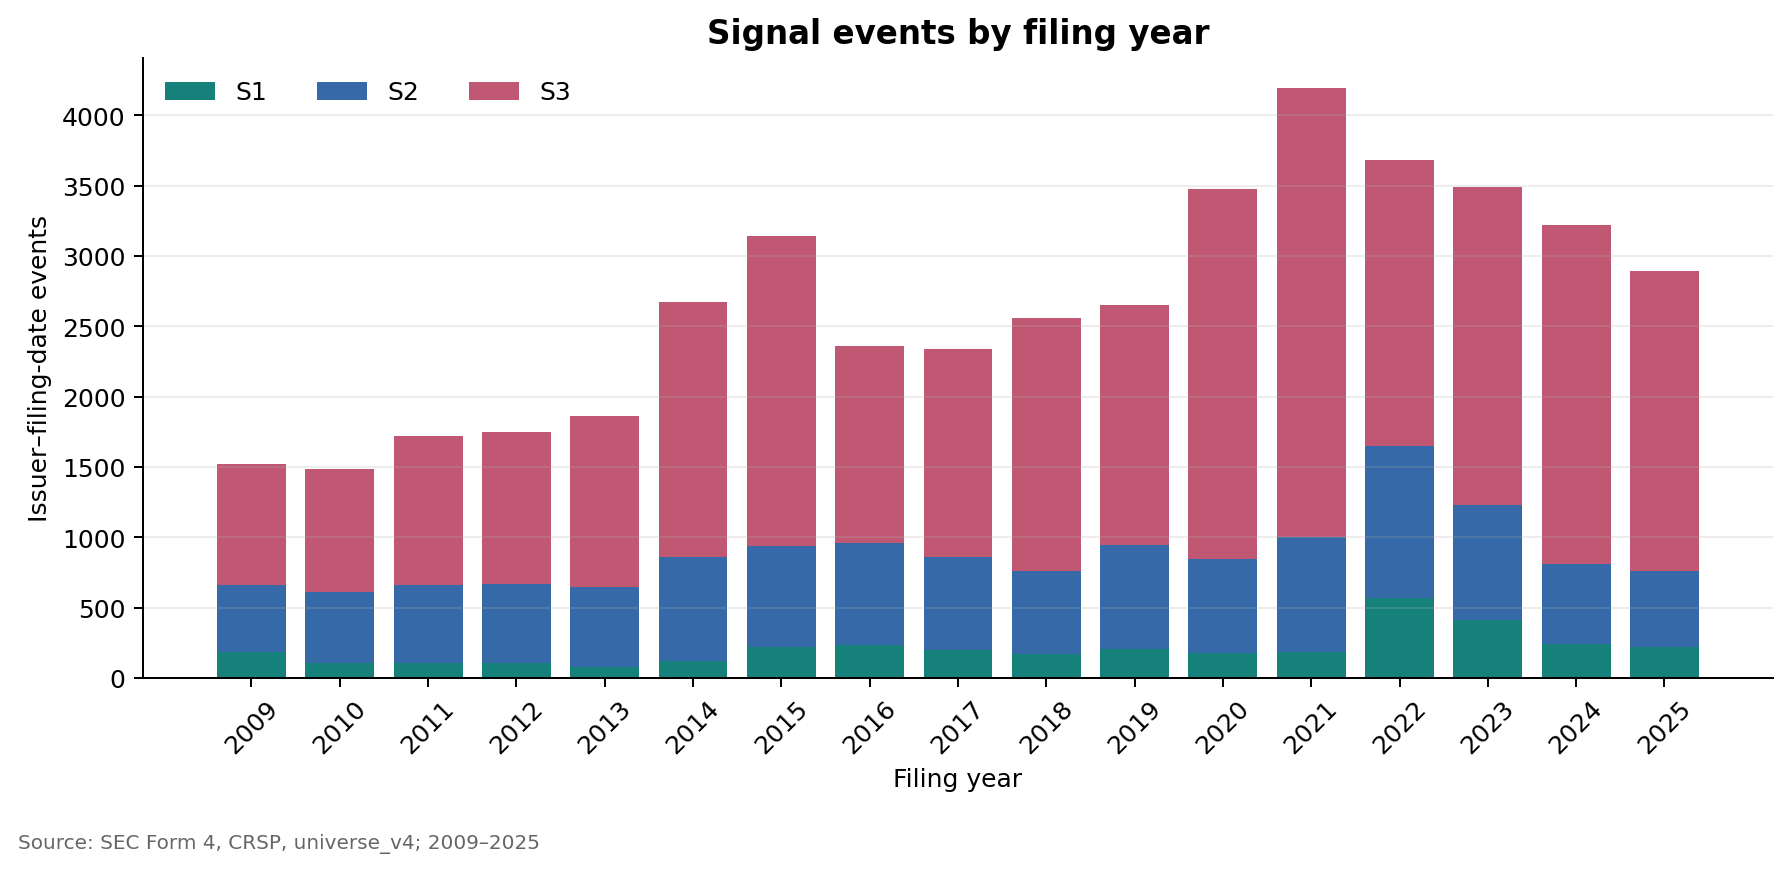

In [2]:
# Price coverage of the universe and number of signal events per filing year.
display(HTML(presentation["coverage"].to_html(index=False)))
events_year = presentation["events_by_year"].pivot(index="year", columns="signal", values="events").fillna(0).astype(int)
display(events_year)
display(Image(filename="results/figures/events_by_year.png"))

## B. Headline table — 5 sessions, 2009–2025

The 95% confidence intervals and p-values use the same two-way issuer × filing-month clustered inference as the tested package.

In [3]:
# Pre-registered headline: 5-session excess return vs XBI, 2009–2025.
headline = format_inference_table(presentation["headline"], ("signal",))
display(HTML(headline.to_html(index=False)))

signal,N,mean (pp),median (pp),hit rate,95% CI (pp),t,p,issuer_clusters,month_clusters
S1,3524,+1.46,-0.59,47.5%,"[+0.74, +2.17]",4.02,8.16e-05,379,204
S2,11280,+0.80,-0.45,47.4%,"[+0.45, +1.14]",4.56,8.72e-06,722,204
S3,30080,-0.07,-0.37,47.0%,"[-0.21, +0.07]",-0.93,3.55e-01,668,204


## C. By horizon

Horizons 1, 2, 3, 5, 10, 21, 42, 63, and 126 all use the same entry rule, total-return inputs, missing-path policy, and inference function. Horizons other than 5 sessions are **descriptive**.

signal,horizon,N,mean (pp),median (pp),hit rate,95% CI (pp),t,p,issuer_clusters,month_clusters
S1,1,3531,+0.54,-0.13,48.3%,"[+0.28, +0.79]",4.10,5.87e-05,379,204
S1,2,3527,+1.02,-0.08,49.6%,"[+0.61, +1.43]",4.89,2.02e-06,379,204
S1,3,3527,+1.12,-0.24,48.6%,"[+0.66, +1.58]",4.79,3.15e-06,379,204
S1,5,3524,+1.46,-0.59,47.5%,"[+0.74, +2.17]",4.02,8.16e-05,379,204
S1,10,3512,+2.26,-1.08,46.5%,"[+0.13, +4.38]",2.10,3.73e-02,378,204
S1,21,3486,+1.52,-3.41,42.3%,"[-0.94, +3.98]",1.22,2.25e-01,375,203
S1,42,3417,+0.58,-5.98,41.3%,"[-2.79, +3.96]",0.34,7.34e-01,370,202
S1,63,3385,+0.59,-9.43,38.3%,"[-3.75, +4.92]",0.27,7.90e-01,367,201
S1,126,3313,+1.46,-18.77,34.0%,"[-6.60, +9.53]",0.36,7.21e-01,357,199
S2,1,11300,+0.24,-0.14,48.1%,"[+0.12, +0.36]",3.92,1.22e-04,722,204


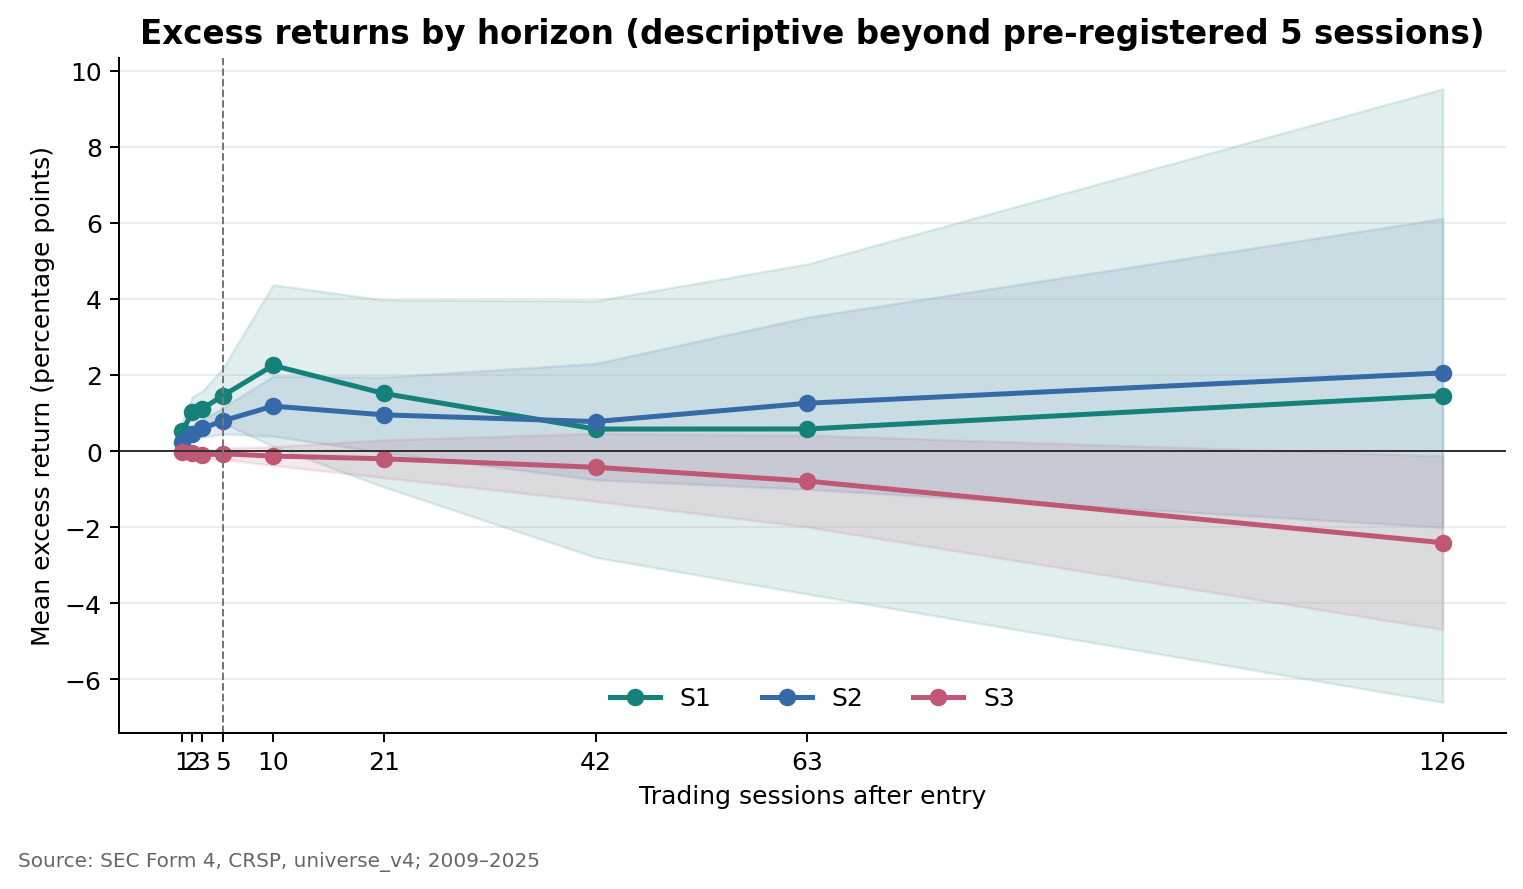

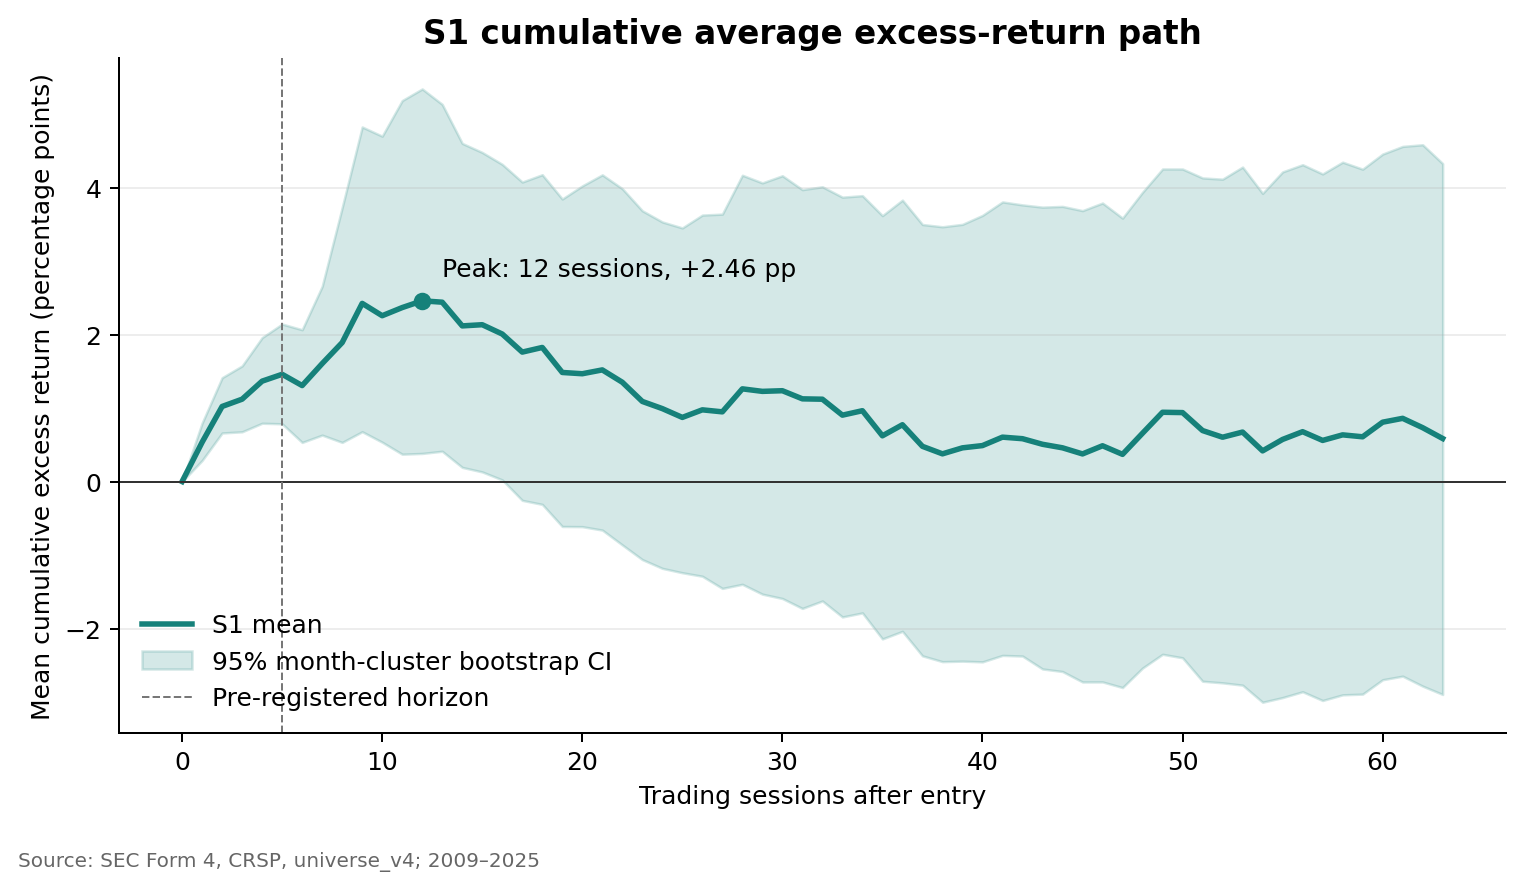

**Descriptive path note.** The S1 cumulative mean peaks at about **12 sessions** (**+2.46 pp**). The drift therefore builds over roughly two trading weeks. The headline horizon remains the pre-registered **5 sessions**; it was not re-chosen after viewing this path. The shaded path interval is a 95% filing-month cluster bootstrap CI (1,000 replications; fixed seed).

In [4]:
# Same statistics on the full horizon grid (5 sessions is the headline; others are descriptive).
horizons = format_inference_table(presentation["horizons"], ("signal", "horizon"))
display(HTML(horizons.to_html(index=False)))
display(Image(filename="results/figures/horizon_profile.png"))
display(Image(filename="results/figures/s1_cumulative_path_ci.png"))
display(Markdown(
    f"**Descriptive path note.** The S1 cumulative mean peaks at about "
    f"**{presentation['peak_session']} sessions** (**{100*presentation['peak_mean']:+.2f} pp**). "
    "The drift therefore builds over roughly two trading weeks. The headline horizon remains the "
    "pre-registered **5 sessions**; it was not re-chosen after viewing this path. The shaded path interval "
    "is a 95% filing-month cluster bootstrap CI (1,000 replications; fixed seed)."
))

## D. Stability

Annual S1 estimates use the same five-session outcome and two-way clustered inference. With only twelve filing-month clusters inside a year, annual intervals are appropriately wide; the sign count is descriptive.

year,N,mean (pp),median (pp),hit rate,95% CI (pp),t,p,issuer_clusters,month_clusters
2009,186,+6.17,+0.95,53.2%,"[-0.09, +12.44]",2.17,5.29e-02,42,12
2010,108,+1.74,+0.08,50.0%,"[-1.63, +5.11]",1.14,2.80e-01,29,12
2011,99,-0.17,-1.79,40.4%,"[-4.36, +4.03]",-0.09,9.33e-01,30,12
2012,104,+2.30,-0.04,50.0%,"[-0.31, +4.91]",1.94,7.84e-02,31,12
2013,81,+3.55,+1.07,54.3%,"[-0.03, +7.13]",2.18,5.19e-02,28,12
2014,121,+0.58,-0.15,49.6%,"[-0.58, +1.74]",1.10,2.96e-01,33,12
2015,219,+3.81,+0.05,50.2%,"[-0.13, +7.75]",2.13,5.70e-02,50,12
2016,234,+0.97,-0.07,49.1%,"[-0.72, +2.67]",1.27,2.31e-01,60,12
2017,196,-0.15,-2.13,39.8%,"[-2.28, +1.98]",-0.16,8.77e-01,71,12
2018,173,+0.43,-1.01,46.8%,"[-2.74, +3.60]",0.30,7.70e-01,54,12


**Positive-year share:** 82.4% of study years.

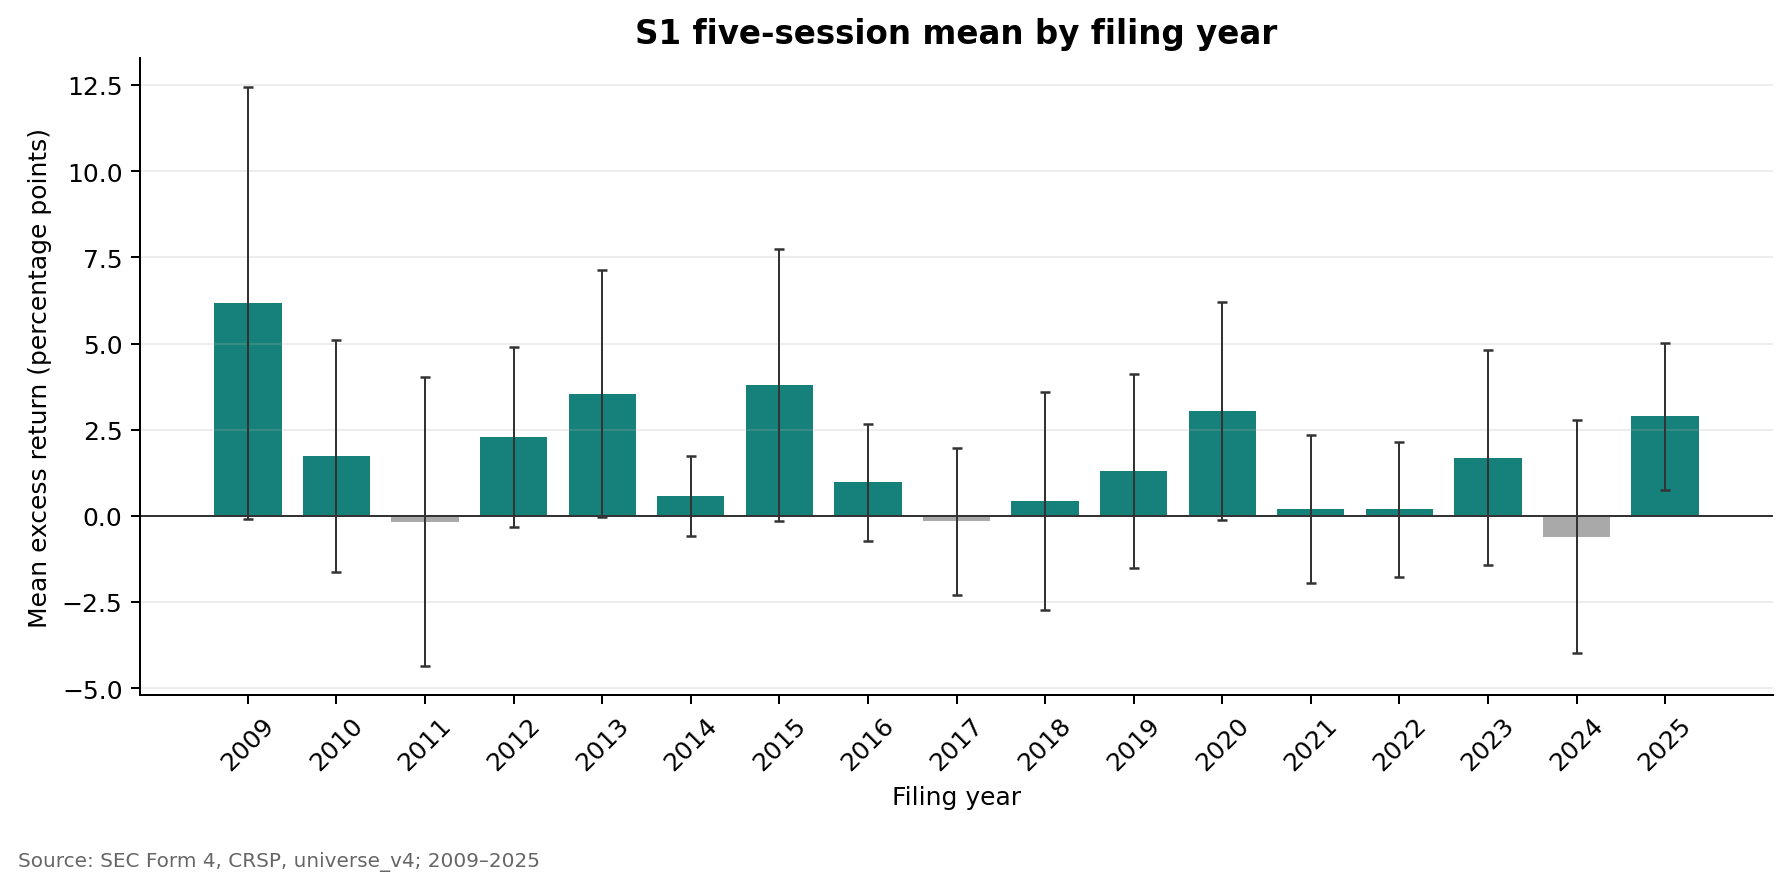

**Pre-specified sub-periods (S1, 5 sessions)**

period,N,mean (pp),median (pp),hit rate,95% CI (pp),t,p,issuer_clusters,month_clusters
2009-2025,3524,+1.46,-0.59,47.5%,"[+0.74, +2.17]",4.02,8.16e-05,379,204
2009-2019,1729,+1.91,-0.36,48.3%,"[+0.91, +2.90]",3.79,2.31e-04,207,132
2020-2025,1795,+1.03,-0.77,46.7%,"[+0.04, +2.02]",2.07,4.18e-02,265,72


In [5]:
# Stability: S1 by filing year and by pre-specified sub-period.
yearly = format_inference_table(presentation["yearly"], ("year",))
display(HTML(yearly.to_html(index=False)))
display(Markdown(f"**Positive-year share:** {100*presentation['positive_year_share']:.1f}% of study years."))
display(Image(filename="results/figures/s1_yearly_stability.png"))

subperiods = format_inference_table(presentation["subperiods"], ("period",))
display(Markdown("**Pre-specified sub-periods (S1, 5 sessions)**"))
display(HTML(subperiods.to_html(index=False)))

## E. Size gradient

All S2 purchases with complete lagged size and turnover features are assigned to small, mid, or large using the same expanding prior-years-only breakpoints that define S1. This is a comparison within purchases, not a new signal definition.

size_tercile,horizon,N,mean (pp),median (pp),hit rate,95% CI (pp),t,p,issuer_clusters,month_clusters
mid,5,3285,+0.82,-0.46,47.4%,"[+0.28, +1.35]",3.00,3.02e-03,427,204
small,5,3524,+1.46,-0.59,47.5%,"[+0.74, +2.17]",4.02,8.16e-05,379,204
large,5,3869,+0.13,-0.37,47.3%,"[-0.19, +0.46]",0.79,4.28e-01,355,204


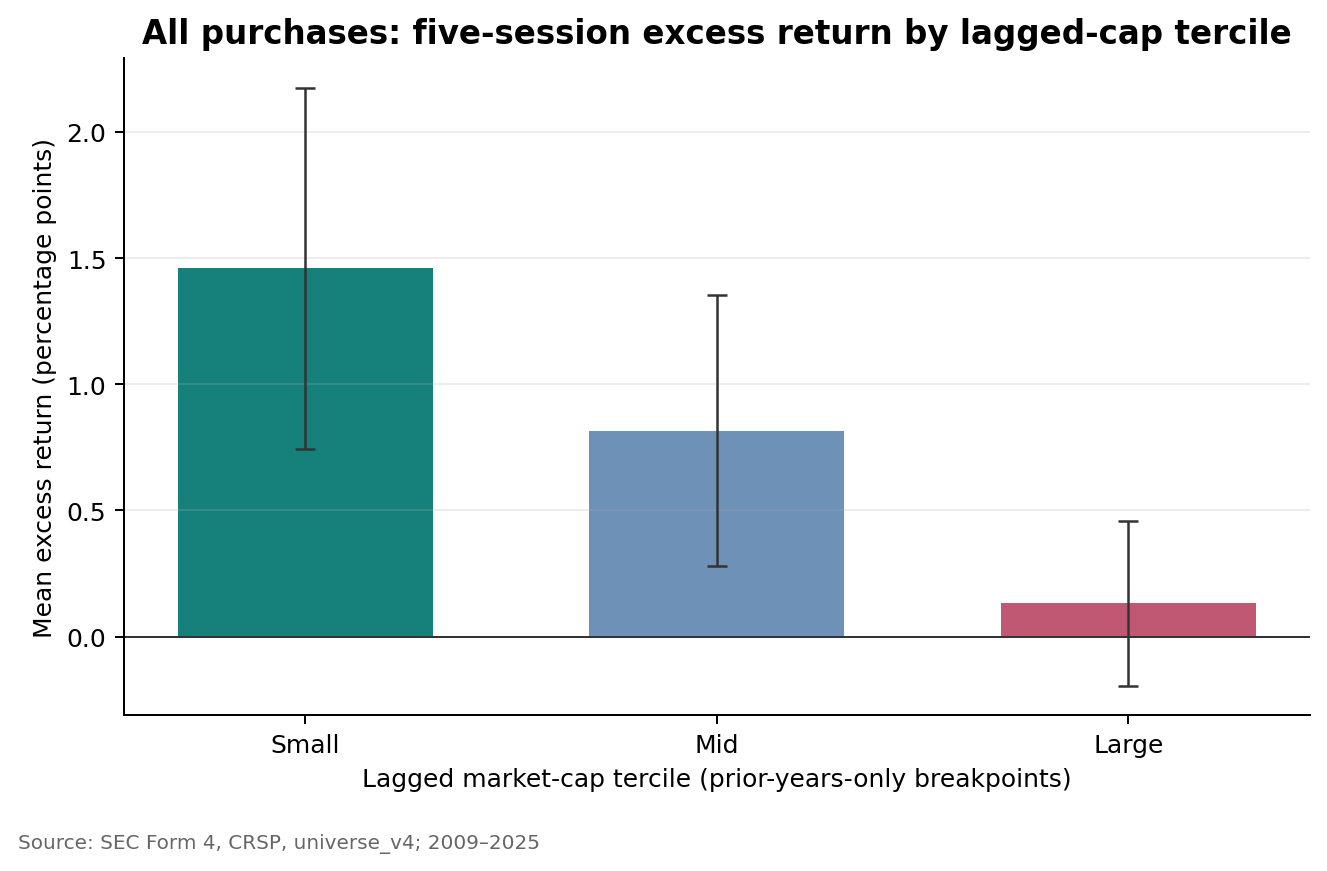

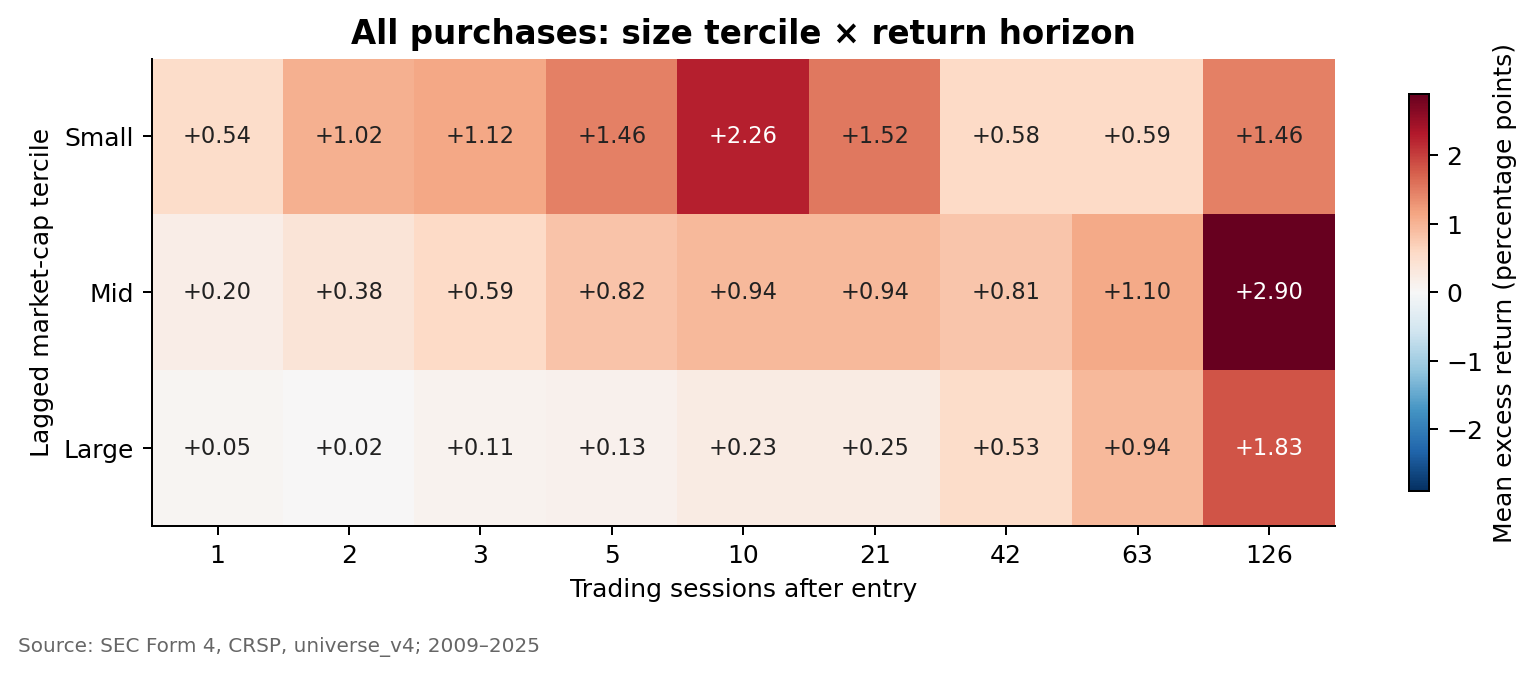

In [6]:
# All purchases split by lagged market-cap tercile (cutoffs from prior years only).
size_five = format_inference_table(presentation["size_five"], ("size_tercile", "horizon"))
display(HTML(size_five.to_html(index=False)))
display(Image(filename="results/figures/size_gradient_h5.png"))
display(Image(filename="results/figures/size_horizon_heatmap.png"))

## F. Distribution & concentration

The histogram is clipped visually to **[−$50, +$100] per $100 invested**; clipping changes only the display, not any statistic. Tail-removal rows remove the trades with the highest S1 excess outcomes. Issuer contribution is the sum of event-level excess dollars within issuer.

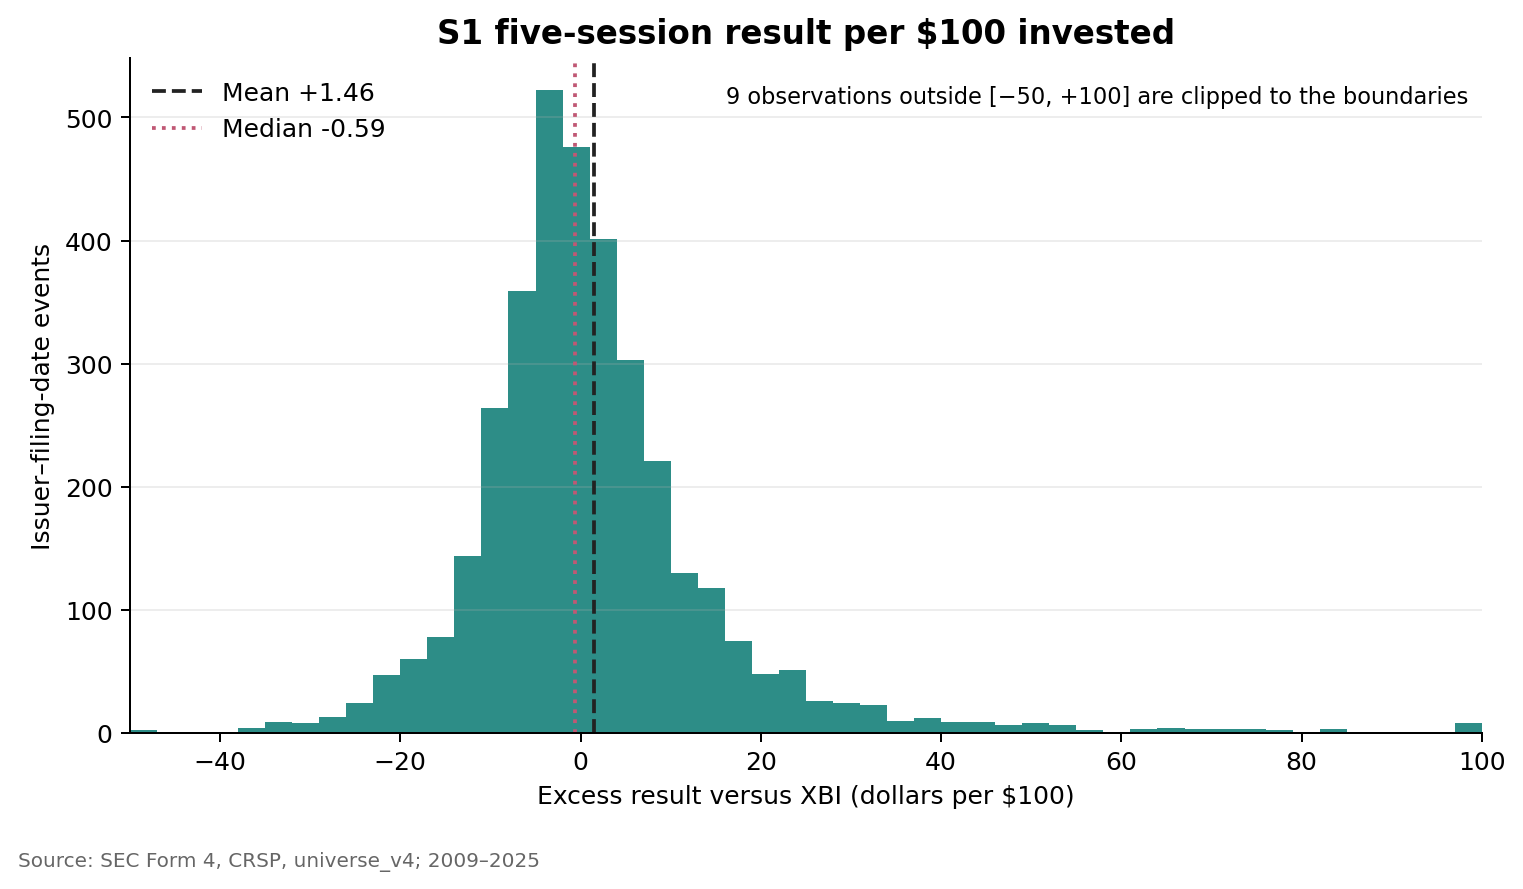

**Outside the displayed range:** 9 observations.

percentile,excess_dollars_per_100
p01,$-26.38
p05,$-16.56
p10,$-11.65
p25,$-6.05
p50,$-0.59
p75,$+6.21
p90,$+15.58
p95,$+24.39
p99,$+52.36


measure,reported value
All S1 trades,$+1.46
After removing top 1% of trades,$+0.57
After removing top 5% of trades,$-0.85
After dropping 5 largest-contribution issuers,$+1.14
Share of total excess from top 10 issuers,44.1%


In [7]:
# Distribution of single-trade outcomes per $100 and dependence on the largest winners.
display(Image(filename="results/figures/s1_per_100_histogram.png"))
display(Markdown(f"**Outside the displayed range:** {presentation['histogram_outside']:,} observations."))

percentiles = presentation["percentiles"].copy()
percentiles["excess_dollars_per_100"] = percentiles["excess_dollars_per_100"].map(lambda x: f"${x:+.2f}")
display(HTML(percentiles.to_html(index=False)))

concentration = presentation["concentration"].copy()
concentration["reported value"] = [
    f"{100*row.value:.1f}%" if row.unit == "share" else f"${row.value:+.2f}"
    for row in concentration.itertuples(index=False)
]
display(HTML(concentration[["measure", "reported value"]].to_html(index=False)))

## G. Example month — real trades

**Fixed selection rule:** the calendar month in 2025 with the most S1 events; ties, if any, are resolved to the earliest month. This rule selects the month without using returns. Purchase amount is the sum of reported code-P transaction values across original Form 4 filings for that issuer-day.

The fixed rule selects **2025-03**, with **28 S1 events**.

Ticker,Company,Filing date,Entry date,Insider role(s),Purchase amount,Stock return,XBI return,Excess return,$ result per $100
PDSB,PDS Biotechnology Corp,2025-03-03,2025-03-04,Director,"$50,001",-6.20%,+0.05%,-6.25 pp,$-6.25
AIM,AIM ImmunoTech Inc.,2025-03-04,2025-03-05,Top executive / chair (CEO & President),"$10,000",-6.16%,-0.76%,-5.40 pp,$-5.40
BCDA,"BioCardia, Inc.",2025-03-04,2025-03-05,Top executive / chair (President and CEO),"$1,055",+0.39%,-0.76%,+1.16 pp,$+1.16
AIM,AIM ImmunoTech Inc.,2025-03-05,2025-03-06,Top executive / chair (CEO & President),"$5,280",-10.65%,-1.25%,-9.40 pp,$-9.40
BCDA,"BioCardia, Inc.",2025-03-05,2025-03-06,Director,"$88,065",-0.39%,-1.25%,+0.86 pp,$+0.86
MAIA,"MAIA Biotechnology, Inc.",2025-03-05,2025-03-06,Director,"$87,500",-8.14%,-1.25%,-6.89 pp,$-6.89
AIM,AIM ImmunoTech Inc.,2025-03-06,2025-03-07,Top executive / chair (CEO & President),"$6,500",-12.78%,-0.19%,-12.59 pp,$-12.59
BCDA,"BioCardia, Inc.",2025-03-07,2025-03-10,Director,"$2,450",+3.15%,+2.38%,+0.77 pp,$+0.77
TNYA,"Tenaya Therapeutics, Inc.",2025-03-07,2025-03-10,10% owner; Director,"$49,999,998",+44.35%,+2.38%,+41.98 pp,$+41.98
CLRB,"Cellectar Biosciences, Inc.",2025-03-12,2025-03-13,Top executive / chair (Chief Operating Officer),"$8,400",+26.87%,+0.72%,+26.15 pp,$+26.15


**Illustration rule:** the three panels show the trade closest to the month’s median five-session excess return, the best trade, and the worst trade. Paths run from −10 to +10 exchange sessions around entry, use total-return levels rebased to 100 at entry, and mark entry (solid vertical line) and the five-session exit (dotted line).

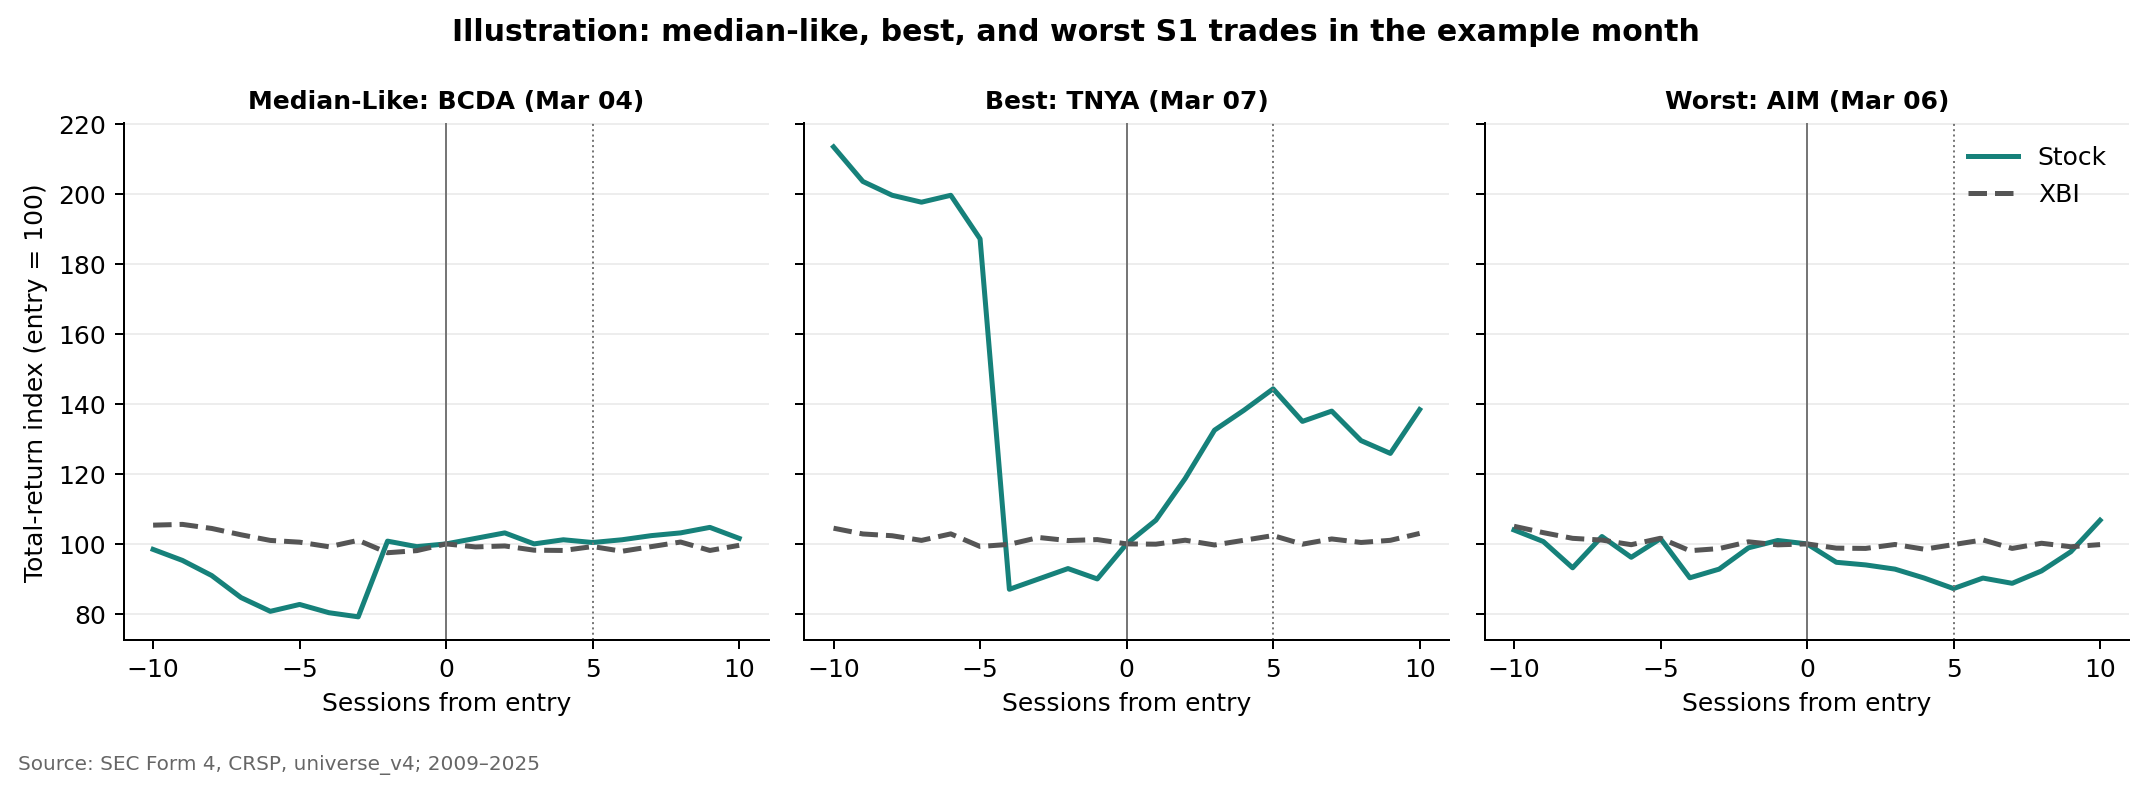

In [8]:
# Illustration: every S1 trade of the month with the most S1 events in 2025 (rule fixed in advance).
display(Markdown(
    f"The fixed rule selects **{presentation['example_month']}**, with "
    f"**{len(presentation['example']):,} S1 events**."
))
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.max_colwidth", 60):
    display(HTML(format_example_table(presentation["example"]).to_html(index=False)))

display(Markdown(
    "**Illustration rule:** the three panels show the trade closest to the month’s median "
    "five-session excess return, the best trade, and the worst trade. Paths run from −10 to +10 "
    "exchange sessions around entry, use total-return levels rebased to 100 at entry, and mark entry "
    "(solid vertical line) and the five-session exit (dotted line)."
))
display(Image(filename="results/figures/example_month_paths.png"))

## H. Seller silence (S4, Hong & Li)

An owner is a routine seller for calendar month *m* in year *Y* when an original Form 4 reports a non-derivative code-S transaction dated in month *m* in both *Y−2* and *Y−1*. The point-in-time signal is frozen on the second US-federal-business day after month end: a routine owner is SSN when no current-year month-*m* sale is public by then, and SSS otherwise. At firm-month level, any SSN owner makes the firm SSN; SSS-only requires at least one SSS owner and no SSN owner. Eligibility is mapped to the effective-dated universe on the availability date. Entry is the first session close strictly after availability. The pre-registered primary horizons are 63 and 126 sessions; the others are descriptive.


### Counts funnel

,stage,arm,horizon,count
0,owners,all,<NA>,7423
1,owner_issuer_pairs,all,<NA>,10121
2,routine_seller_months,all,<NA>,11067
3,eligible_firm_months,SSN,<NA>,2935
4,eligible_firm_months,SSS_only,<NA>,1515
5,priced,SSN,1,2933
6,priced,SSN,2,2932
7,priced,SSN,3,2931
8,priced,SSN,5,2929
9,priced,SSN,10,2920


### Results by horizon and period

,period,horizon,N_SSN,N_SSS_only,SSN_mean,SSS_only_mean,difference,clustered_se,t,p_two_sided
0,2009-2025,1,2933,1515,+0.034,+0.124,-0.089,+0.143,-0.625043,0.532648
1,2009-2025,2,2932,1515,-0.036,+0.208,-0.244,+0.192,-1.268798,0.205973
2,2009-2025,3,2931,1514,+0.003,+0.224,-0.221,+0.240,-0.919594,0.358882
3,2009-2025,5,2929,1513,+0.004,+0.154,-0.150,+0.257,-0.584616,0.559458
4,2009-2025,10,2920,1511,+0.122,+0.483,-0.361,+0.342,-1.055309,0.292545
5,2009-2025,21,2882,1497,+0.869,+1.032,-0.163,+0.655,-0.248763,0.803798
6,2009-2025,42,2847,1480,+0.902,+0.092,+0.810,+0.969,0.836115,0.404088
7,2009-2025,63,2805,1460,+0.837,-0.076,+0.912,+1.147,0.795563,0.427234
8,2009-2025,126,2648,1394,+0.361,-0.969,+1.331,+1.994,0.667579,0.505188
9,2009-2019,1,1457,723,-0.001,+0.104,-0.105,+0.124,-0.847847,0.398070


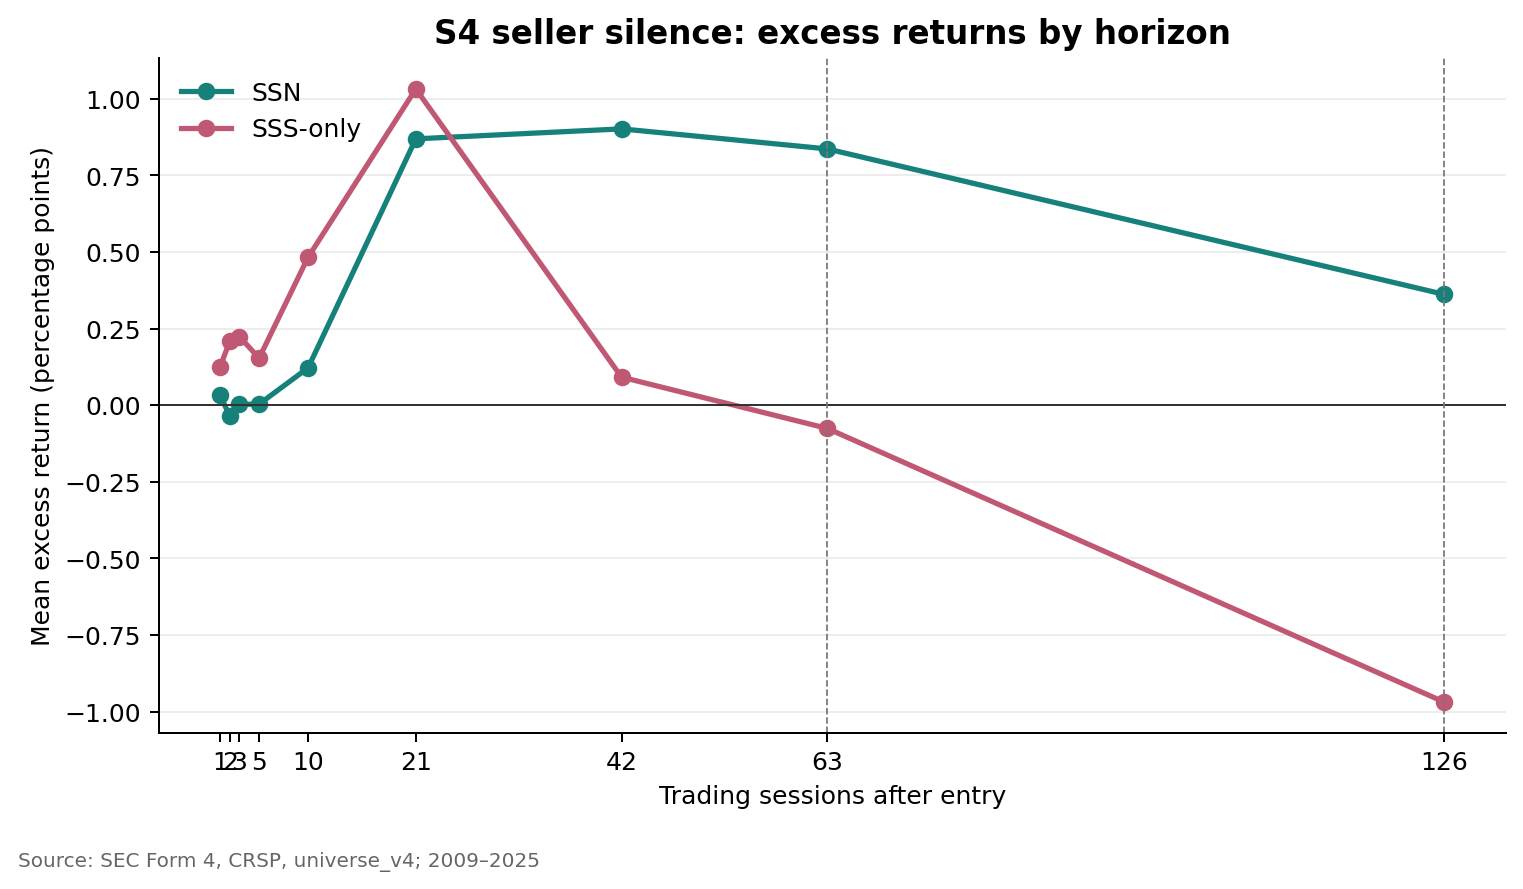

In [9]:
# S4: Hong & Li seller silence (routine sellers who stop selling vs those who keep selling).
from signals.seller_silence.ssn import run_ssn
from shared.engine import figures

ssn = run_ssn(analysis["universe"], analysis["levels"], analysis["benchmark"], config)
s4_counts = ssn["counts"]
s4_results = ssn["results"]
figures.seller_silence(s4_results, config.results_dir / "figures" / "seller_silence.png")
display(Markdown("### Counts funnel"))
display(s4_counts)
display(Markdown("### Results by horizon and period"))
s4_show = s4_results[["period", "horizon", "N_SSN", "N_SSS_only", "SSN_mean", "SSS_only_mean", "difference", "clustered_se", "t", "p_two_sided"]].copy()
for column in ["SSN_mean", "SSS_only_mean", "difference", "clustered_se"]:
    s4_show[column] = (100 * s4_show[column]).map(lambda value: f"{value:+.3f}")
display(s4_show)
display(Image(filename="results/figures/seller_silence.png"))

## I. Data sanity checks

Checks flag observations; they never silently alter the official samples. The robustness table separately excludes flagged events. Ownership continuity cannot be tested from the normalized archive because it retains only P/S rows; grants, exercises, and gifts remain in the raw SEC ZIPs, so no continuity proxy is fabricated here.


In [10]:
# Data sanity flags (direction, dates, prices, duplicates, large trades, market data) and results without flagged events.
from shared.engine.sanity import run_sanity

sanity = run_sanity(analysis, ssn, config)
sanity_summary = sanity["summary"]
sanity_robustness = sanity["robustness"]
display(Markdown("### Flag summary"))
display(sanity_summary)
display(Markdown("### Excluding flagged events: official versus robustness"))
robust_show = sanity_robustness.copy()
for column in ["official_effect", "robust_effect"]:
    robust_show[column] = (100 * robust_show[column]).map(lambda value: f"{value:+.3f} pp")
display(robust_show)

shared/engine/sanity.py:290: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  robust_sales = robust_sales.loc[~robust_sales["_bad"].fillna(False)].drop(columns="_bad")


shared/engine/sanity.py:244: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  outcomes.loc[outcomes["any_market_flag"].fillna(False), "excess_return"] = np.nan


### Flag summary

,signal,check,events_checked,flagged,percent_flagged
0,S1,direction_consistency,11193,22,0.196551
1,S1,transaction_date_after_filing_date,11193,0,0.000000
2,S1,filing_lag_over_30_days,11193,235,2.099526
3,S1,reported_price_outside_CRSP_low_high_pm1pct,11193,1063,9.497007
4,S1,likely_reported_price_scale_error_10x,11193,34,0.303761
5,S1,identical_owner_date_shares_price_multiple_fil...,11193,332,2.966140
6,S1,reported_value_over_1pct_lagged_market_cap,11193,1127,10.068793
7,S1,reported_value_over_trailing_20_session_averag...,11193,1134,10.131332
8,S1,extreme_daily_return_gt_200pct,3537,1,0.028273
9,S1,missing_sessions_in_window,3537,13,0.367543


### Excluding flagged events: official versus robustness

,signal,period,horizon,estimand,official_N,official_effect,official_t,official_p,robust_N,robust_effect,robust_t,robust_p
0,S1,2009-2025,5,mean_excess,3524,+1.459 pp,4.021125,0.000082,2894,+1.118 pp,3.065176,0.002476
1,S1,2009-2019,5,mean_excess,1729,+1.907 pp,3.787385,0.000231,1419,+1.611 pp,3.417970,0.000843
2,S1,2020-2025,5,mean_excess,1795,+1.028 pp,2.072614,0.041840,1475,+0.643 pp,1.220910,0.226276
3,S4,2009-2025,63,SSN_minus_SSS_only,4265,+0.912 pp,0.795563,0.427234,4151,+0.363 pp,0.320152,0.749189
4,S4,2009-2025,126,SSN_minus_SSS_only,4042,+1.331 pp,0.667579,0.505188,3930,+0.559 pp,0.291234,0.771180
5,S4,2009-2019,63,SSN_minus_SSS_only,2128,+0.111 pp,0.075816,0.939681,2083,+0.180 pp,0.117591,0.906572
6,S4,2009-2019,126,SSN_minus_SSS_only,2073,-1.999 pp,-0.771773,0.441639,2027,-1.928 pp,-0.741947,0.459447
7,S4,2020-2025,63,SSN_minus_SSS_only,2137,+1.754 pp,0.982129,0.329569,2068,+0.578 pp,0.340724,0.734377
8,S4,2020-2025,126,SSN_minus_SSS_only,1969,+4.832 pp,1.545117,0.127249,1903,+3.178 pp,1.092318,0.278788


## J. Descriptive conditioning

S1 and S2 are split by exclusive buyer role and prior-years-only reported-dollar terciles. S3 is split by the Cohen–Malloy–Pomorski three-prior-year seller classification. All rows cover 2009–2025, use the full horizon grid, and retain issuer × filing-month clustered inference. These are descriptive cuts, not new confirmatory tests.

In [11]:
# Descriptive splits by insider role, trade size and seller type; saved to results/conditioning.csv.
from signals.smallcap_purchases.conditioning import conditioning_table

conditioning = conditioning_table(analysis["outcomes"], config)
conditioning.to_csv(config.results_dir / "conditioning.csv", index=False)
official_summary = write_report(analysis, config, s4_results, conditioning)
conditioning_show = format_inference_table(
    conditioning, ("signal", "dimension", "group", "horizon")
)
display(HTML(conditioning_show.to_html(index=False)))


signal,dimension,group,horizon,N,mean (pp),median (pp),hit rate,95% CI (pp),t,p,issuer_clusters,month_clusters
S1,buyer_role,senior_executive,1,1498,+0.72,-0.02,49.7%,"[+0.29, +1.14]",3.33,1.05e-03,289,193
S1,buyer_role,senior_executive,2,1497,+0.95,-0.07,49.7%,"[+0.38, +1.53]",3.28,1.25e-03,289,193
S1,buyer_role,senior_executive,3,1497,+1.21,+0.01,50.0%,"[+0.51, +1.91]",3.40,8.11e-04,289,193
S1,buyer_role,senior_executive,5,1497,+1.64,-0.40,47.8%,"[+0.67, +2.60]",3.34,1.01e-03,289,193
S1,buyer_role,senior_executive,10,1491,+1.16,-1.21,46.1%,"[-0.25, +2.56]",1.62,1.06e-01,289,193
S1,buyer_role,senior_executive,21,1480,+1.61,-3.74,41.4%,"[-1.21, +4.43]",1.13,2.60e-01,286,192
S1,buyer_role,senior_executive,42,1457,+0.65,-7.25,39.4%,"[-3.28, +4.57]",0.33,7.45e-01,283,191
S1,buyer_role,senior_executive,63,1451,+0.06,-10.21,35.6%,"[-6.06, +6.18]",0.02,9.85e-01,282,190
S1,buyer_role,senior_executive,126,1426,-1.71,-20.97,32.3%,"[-11.64, +8.21]",-0.34,7.34e-01,277,187
S1,buyer_role,other_officers,1,243,+0.34,-0.35,46.9%,"[-0.34, +1.03]",0.99,3.26e-01,116,100


## K. Takeaways & caveats

In [12]:
# Takeaways computed from the numbers above.
s1 = presentation["headline"].set_index("signal").loc["S1"]
size = presentation["size_five"].set_index("size_tercile")
median_dollars = float(presentation["percentiles"].set_index("percentile").loc["p50", "excess_dollars_per_100"])
trimmed_1 = float(presentation["concentration"].set_index("measure").loc["After removing top 1% of trades", "value"])

display(Markdown(f'''
- **Headline:** S1 averages **{100*s1['mean']:+.2f} pp** over XBI after 5 sessions (N={int(s1['N']):,}, t={s1['t']:.2f}, p={s1['p_two_sided']:.2e}).
- **Stability:** the S1 mean is positive in **{100*presentation['positive_year_share']:.1f}%** of study years; the sub-period table shows a smaller post-2020 estimate.
- **Size:** at 5 sessions the mean declines from **{100*size.loc['small','mean']:+.2f} pp** in the small tercile to **{100*size.loc['large','mean']:+.2f} pp** in the large tercile.
- **Horizon:** the descriptive S1 path peaks near session **{presentation['peak_session']}** at **{100*presentation['peak_mean']:+.2f} pp**, but the pre-registered headline remains 5 sessions; the horizon was not re-chosen.
- **Skew:** the median is **${median_dollars:+.2f}** per $100 versus a mean of **${100*s1['mean']:+.2f}**; after removing the top 1% of trades the mean is **${trimmed_1:+.2f}**.
- **Gross returns:** no transaction costs, bid–ask spread, or market impact are deducted; **{100*presentation['low_price_share']:.1f}%** of complete S1 entries are below $5.
- **Research status:** the small-cap result had an exploratory origin on 2009–2025. A frozen 2026 out-of-sample test is ready but awaits the required 2026 price data.
'''))


- **Headline:** S1 averages **+1.46 pp** over XBI after 5 sessions (N=3,524, t=4.02, p=8.16e-05).
- **Stability:** the S1 mean is positive in **82.4%** of study years; the sub-period table shows a smaller post-2020 estimate.
- **Size:** at 5 sessions the mean declines from **+1.46 pp** in the small tercile to **+0.13 pp** in the large tercile.
- **Horizon:** the descriptive S1 path peaks near session **12** at **+2.46 pp**, but the pre-registered headline remains 5 sessions; the horizon was not re-chosen.
- **Skew:** the median is **$-0.59** per $100 versus a mean of **$+1.46**; after removing the top 1% of trades the mean is **$+0.57**.
- **Gross returns:** no transaction costs, bid–ask spread, or market impact are deducted; **89.7%** of complete S1 entries are below $5.
- **Research status:** the small-cap result had an exploratory origin on 2009–2025. A frozen 2026 out-of-sample test is ready but awaits the required 2026 price data.


### Prior-study robustness record

The following results come from **earlier pre-registered studies (v1–v6, 24 Sep 2026), not from this notebook**. Their code and outputs are kept in a local research archive (not in this repository, available on request).

| Check | Result |
|---|---|
| Not a rebound (small-cap purchases, SIC-based universe, excess_5 = a + b·prior 5-day excess) | a = +1.39 pp, t = 3.93, one-sided p = 6e-5; 2009–19 +1.64 pp, 2020–25 +1.18 pp |
| Replication on the historical biotech universe with partial price coverage (v6) | +1.51 pp, N = 2,684, t = 3.91 (reproduced exactly by `tests/run_tests.py`) |
| Other pre-registered hypotheses (routine vs opportunistic insiders, Hong–Li seller silence, buys after a crash, open-market vs financing purchases, attention/turnover, filter combinations) | none supported; 19 confirmatory tests in total, the small-cap purchase drift is the only result that survives a Holm correction across all of them |

### Caveats

- Confidence intervals describe uncertainty under the stated issuer/month clustering or month-cluster bootstrap; they do not correct for the exploratory origin of S1.
- Missing or delisted forward paths are missing, never zero-filled. Historical GICS is effective-dated but not publication-vintage, and current-CIK fallback remains a historical-identity limitation.
- The example month is an illustration selected only by event count. It is not a portfolio backtest and includes no trading-cost model.
- Horizons other than 5 sessions, annual slices, the size heatmap, concentration diagnostics, and the example trades are descriptive.